# Clasificación multiclase del riesgo de burnout en población Gen Z mediante redes neuronales multicapa



## 1. Protocolo experimental

Se aplica el siguiente flujo:

1. Carga del dataset `GenZ_dataset.xlsx`.
2. Limpieza y codificación de la variable objetivo `Burnout_Risk`.
3. Partición estratificada en train/validation/test: 80% / 10% / 10%.
4. Preprocesado ajustado solo con train:
   - variables numéricas: estandarización z-score;
   - variables categóricas: one-hot encoding.
5. Cálculo de pesos de clase para compensar el desbalanceo.
6. Entrenamiento de todos los modelos con:
   - mismas épocas máximas;
   - mismo batch size;
   - EarlyStopping común;
   - ReduceLROnPlateau común;
   - misma función de pérdida;
   - mismas métricas de evaluación.
7. Comparación final mediante accuracy, precision, recall y F1-score por clase.

## 2. Configuración general

Cambia únicamente `DATA_PATH` si el archivo Excel está en otra carpeta. El resto de parámetros quedan centralizados para que el experimento sea reproducible y fácil de defender.

In [1]:
# ============================================================
# CONFIGURACIÓN GENERAL DEL EXPERIMENTO
# ============================================================

from pathlib import Path

DATA_PATH = Path("GenZ_dataset.xlsx")   # Cambia esta ruta si el Excel está en otra carpeta
TARGET_COL = "Burnout_Risk"

CLASS_NAMES = ["Low", "Medium", "High"]
CLASS_TO_INT = {"Low": 0, "Medium": 1, "High": 2}

RANDOM_STATE = 42
TEST_SIZE = 0.10
VAL_SIZE_TOTAL = 0.10

MAX_EPOCHS = 50          # mismas épocas máximas para todos los modelos
BATCH_SIZE = 128         # mismo batch size para todos los modelos
PATIENCE = 10            # EarlyStopping común
LR_PATIENCE = 5          # ReduceLROnPlateau común
MIN_DELTA = 1e-4

RUN_KERAS_TUNER = True   # ponlo en False si no quieres ejecutar la búsqueda automática
SAVE_OUTPUTS = True
OUTPUT_DIR = Path("outputs_burnout_unified")

## 3. Librerías y reproducibilidad

In [2]:
import os
import random
import json
import warnings

# ------------------------------------------------------------
# Reproducibilidad
# ------------------------------------------------------------
# Estas variables deben fijarse antes de importar TensorFlow.
# Ayudan a reducir la variabilidad entre ejecuciones, aunque en GPU
# puede seguir existiendo una pequeña no determinación numérica.
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")


def set_global_seed(seed: int = 42):
    """Fija semillas para mejorar la reproducibilidad."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception as e:
        print("No se pudo activar determinismo completo:", e)


set_global_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.21.0
GPU disponible: []


## 4. Carga del dataset

El notebook espera un archivo Excel con una columna objetivo llamada `Burnout_Risk`.

In [3]:
df = pd.read_excel(DATA_PATH)

print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nPrimeras filas:")
display(df.head())

print("\nDistribución original de Burnout_Risk:")
display(df[TARGET_COL].value_counts(dropna=False))

Dimensiones del dataset: (10000, 22)

Columnas:
['Age', 'Gender', 'Country', 'Student_Working_Status', 'Daily_Social_Media_Hours', 'Screen_Time_Hours', 'Night_Scrolling_Frequency', 'Online_Gaming_Hours', 'Content_Type_Preference', 'Exercise_Frequency_per_Week', 'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day', 'Overthinking_Score', 'Anxiety_Score', 'Mood_Stability_Score', 'Social_Comparison_Index', 'Sleep_Quality_Score', 'Motivation_Level', 'Emotional_Fatigue_Score', 'Wellbeing_Index', 'Burnout_Risk']

Primeras filas:


,Age,Gender,Country,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,...,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
0,24,Male,Canada,Working,4.81,6.93,2.61,2.07,News,5.41,...,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium
1,21,Male,USA,Student,4.16,7.94,1.85,3.58,Gaming,3.41,...,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium
2,25,Male,Pakistan,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,...,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High
3,22,Female,Pakistan,Student,4.41,7.34,4.51,3.37,Educational,2.19,...,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High
4,24,Male,Pakistan,Student,2.97,5.76,2.36,1.77,Educational,4.93,...,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium



Distribución original de Burnout_Risk:


Burnout_Risk
High      5388
Medium    4548
Low         64
Name: count, dtype: int64

## 5. Definición de predictores y variable objetivo

Se normalizan los nombres de las clases para evitar errores por mayúsculas, espacios o formatos distintos.

In [4]:
if TARGET_COL not in df.columns:
    raise ValueError(f"La columna objetivo '{TARGET_COL}' no existe en el dataset.")

X = df.drop(columns=[TARGET_COL]).copy()
y_raw = df[TARGET_COL].astype(str).str.strip().str.capitalize()

y = y_raw.map(CLASS_TO_INT)

if y.isna().any():
    unknown_labels = sorted(y_raw[y.isna()].unique())
    raise ValueError(
        f"Hay etiquetas no reconocidas en {TARGET_COL}: {unknown_labels}. "
        f"Se esperaban: {CLASS_NAMES}"
    )

y = y.astype(int)

print("Mapeo de clases:")
print(CLASS_TO_INT)

print("\nDistribución target codificado:")
display(pd.DataFrame({
    "clase": CLASS_NAMES,
    "codigo": [CLASS_TO_INT[c] for c in CLASS_NAMES],
    "n": [int((y == CLASS_TO_INT[c]).sum()) for c in CLASS_NAMES],
    "porcentaje": [float((y == CLASS_TO_INT[c]).mean() * 100) for c in CLASS_NAMES],
}))

Mapeo de clases:
{'Low': 0, 'Medium': 1, 'High': 2}

Distribución target codificado:


,clase,codigo,n,porcentaje
0,Low,0,64,0.64
1,Medium,1,4548,45.48
2,High,2,5388,53.88


## 6. Partición estratificada train / validation / test

Se separa primero test y después validation. Así se conserva test como conjunto final no usado durante la selección de modelos.

In [5]:
# 1) Train+validation / test
X_trainval, X_test, y_trainval, y_test_int = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

# 2) Train / validation
# Si test = 10% y validation total = 10%, entonces validation dentro de trainval es 0.10 / 0.90
val_size_inside_trainval = VAL_SIZE_TOTAL / (1.0 - TEST_SIZE)

X_train, X_val, y_train_int, y_val_int = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_size_inside_trainval,
    stratify=y_trainval,
    random_state=RANDOM_STATE,
)

print("Tamaños finales:")
print("Train:", X_train.shape, y_train_int.shape)
print("Validation:", X_val.shape, y_val_int.shape)
print("Test:", X_test.shape, y_test_int.shape)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n_total": [len(y_train_int), len(y_val_int), len(y_test_int)],
})

for cls in CLASS_NAMES:
    cls_id = CLASS_TO_INT[cls]
    split_summary[cls] = [
        int((y_train_int == cls_id).sum()),
        int((y_val_int == cls_id).sum()),
        int((y_test_int == cls_id).sum()),
    ]

display(split_summary)

Tamaños finales:
Train: (7999, 21) (7999,)
Validation: (1001, 21) (1001,)
Test: (1000, 21) (1000,)


,split,n_total,Low,Medium,High
0,train,7999,51,3638,4310
1,validation,1001,7,455,539
2,test,1000,6,455,539


## 7. Preprocesado tabular sin fuga de información

El `ColumnTransformer` se ajusta exclusivamente con el conjunto de entrenamiento. Después se aplica a validation y test.

In [6]:
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("Columnas numéricas:", num_cols)
print("Columnas categóricas:", cat_cols)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop",
)

x_train = preprocessor.fit_transform(X_train).astype("float32")
x_val = preprocessor.transform(X_val).astype("float32")
x_test = preprocessor.transform(X_test).astype("float32")

y_train = to_categorical(y_train_int, num_classes=len(CLASS_NAMES))
y_val = to_categorical(y_val_int, num_classes=len(CLASS_NAMES))
y_test = to_categorical(y_test_int, num_classes=len(CLASS_NAMES))

print("x_train:", x_train.shape)
print("x_val:", x_val.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

INPUT_DIM = x_train.shape[1]
N_CLASSES = len(CLASS_NAMES)

Columnas numéricas: ['Age', 'Daily_Social_Media_Hours', 'Screen_Time_Hours', 'Night_Scrolling_Frequency', 'Online_Gaming_Hours', 'Exercise_Frequency_per_Week', 'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day', 'Overthinking_Score', 'Anxiety_Score', 'Mood_Stability_Score', 'Social_Comparison_Index', 'Sleep_Quality_Score', 'Motivation_Level', 'Emotional_Fatigue_Score', 'Wellbeing_Index']
Columnas categóricas: ['Gender', 'Country', 'Student_Working_Status', 'Content_Type_Preference']
x_train: (7999, 34)
x_val: (1001, 34)
x_test: (1000, 34)
y_train: (7999, 3)
y_val: (1001, 3)
y_test: (1000, 3)


## 8. Pesos de clase

Se calculan con la opción `balanced`, de forma inversamente proporcional a la frecuencia de aparición de cada clase en entrenamiento.

Estos pesos se pasan a `model.fit(..., class_weight=class_weights)`, por lo que un error en la clase minoritaria contribuye más a la pérdida durante el entrenamiento.

In [7]:
classes = np.unique(y_train_int)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_int,
)

class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

class_weight_table = pd.DataFrame({
    "clase": [CLASS_NAMES[int(c)] for c in classes],
    "codigo": classes.astype(int),
    "n_train": [int((y_train_int == c).sum()) for c in classes],
    "porcentaje_train": [float((y_train_int == c).mean() * 100) for c in classes],
    "peso_clase": weights,
})

class_weight_table["porcentaje_train"] = class_weight_table["porcentaje_train"].round(3)
class_weight_table["peso_clase"] = class_weight_table["peso_clase"].round(4)

display(class_weight_table)
print("class_weights para Keras:", class_weights)


,clase,codigo,n_train,porcentaje_train,peso_clase
0,Low,0,51,0.638,52.2810
1,Medium,1,3638,45.481,0.7329
2,High,2,4310,53.882,0.6186


class_weights para Keras: {0: 52.28104575163399, 1: 0.7329118563313176, 2: 0.6186388244392885}


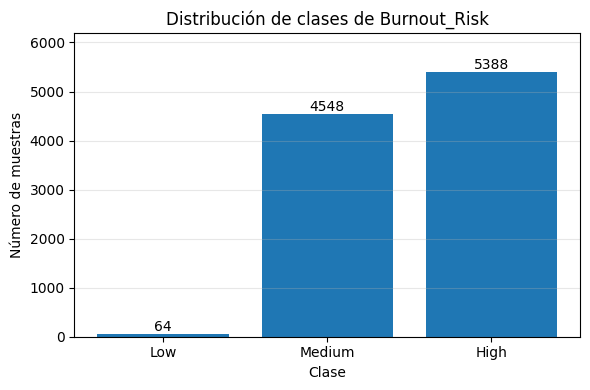

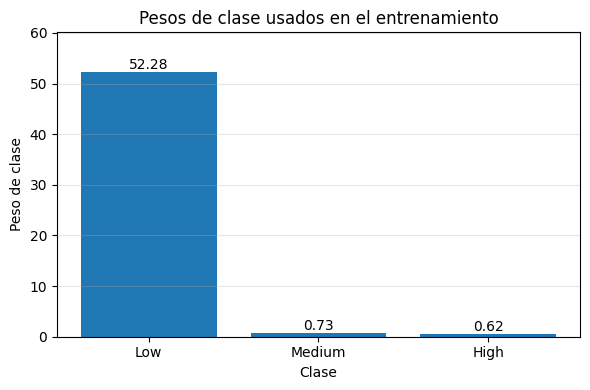

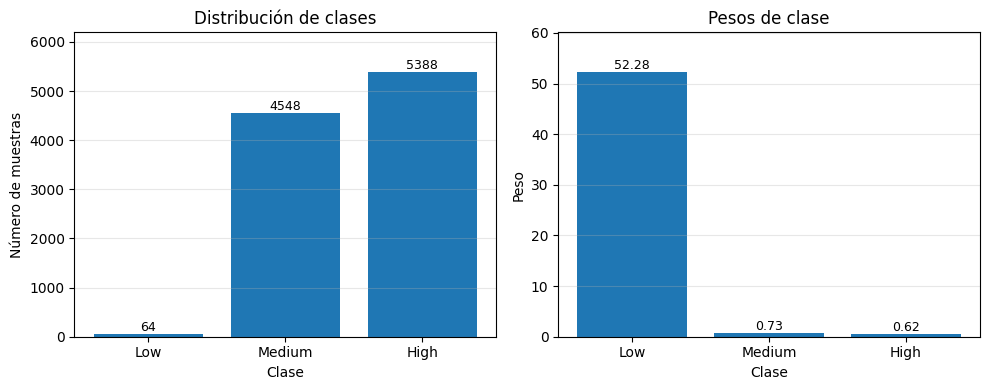

In [8]:
# ============================================================
# Gráficas de distribución de clases y pesos de clase
# ============================================================

class_counts = (
    pd.Series(y)
    .map({0: "Low", 1: "Medium", 2: "High"})
    .value_counts()
    .reindex(CLASS_NAMES)
)

class_weight_series = (
    class_weight_table
    .set_index("clase")["peso_clase"]
    .reindex(CLASS_NAMES)
)

# ------------------------------------------------------------
# Figura 1: distribución de clases
# ------------------------------------------------------------
plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index, class_counts.values)

plt.title("Distribución de clases de Burnout_Risk")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, class_counts.max() * 1.15)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


# ------------------------------------------------------------
# Figura 2: pesos de clase usados durante el entrenamiento
# ------------------------------------------------------------
plt.figure(figsize=(6, 4))
bars = plt.bar(class_weight_series.index, class_weight_series.values)

plt.title("Pesos de clase usados en el entrenamiento")
plt.xlabel("Clase")
plt.ylabel("Peso de clase")
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, class_weight_series.max() * 1.15)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()

if SAVE_OUTPUTS:
    plt.savefig(OUTPUT_DIR / "class_weights.png", dpi=300, bbox_inches="tight")

plt.show()


# ------------------------------------------------------------
# Figura combinada: distribución + pesos
# Útil para Overleaf si se quiere ahorrar espacio.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

bars0 = axes[0].bar(class_counts.index, class_counts.values)
axes[0].set_title("Distribución de clases")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Número de muestras")
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_ylim(0, class_counts.max() * 1.15)

for bar in bars0:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

bars1 = axes[1].bar(class_weight_series.index, class_weight_series.values)
axes[1].set_title("Pesos de clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Peso")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim(0, class_weight_series.max() * 1.15)

for bar in bars1:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()

if SAVE_OUTPUTS:
    plt.savefig(OUTPUT_DIR / "class_distribution_and_weights.png", dpi=300, bbox_inches="tight")

plt.show()


## 9. Funciones comunes de entrenamiento y evaluación

Esta es la parte clave para que el trabajo quede bien unificado. Todos los modelos pasan por la misma función `fit_and_evaluate_model`.

In [9]:
class MacroF1Callback(tf.keras.callbacks.Callback):
    """
    Calcula F1 macro en entrenamiento y validación al final de cada época.

    Se guardan:
    - logs['train_macro_f1']
    - logs['val_macro_f1']

    Así las curvas de Macro F1 quedan igual de claras que las curvas de
    accuracy: train macro F1 frente a validation macro F1.
    """

    def __init__(
        self,
        x_train,
        y_train_int,
        x_val,
        y_val_int,
        batch_size=128,
        verbose=0,
    ):
        super().__init__()
        self.x_train = x_train
        self.y_train_int = np.asarray(y_train_int)
        self.x_val = x_val
        self.y_val_int = np.asarray(y_val_int)
        self.batch_size = batch_size
        self.verbose = verbose

    def _compute_macro_f1(self, x_data, y_true_int):
        y_prob = self.model.predict(
            x_data,
            batch_size=self.batch_size,
            verbose=0,
        )
        y_pred_int = np.argmax(y_prob, axis=1)

        return f1_score(
            y_true_int,
            y_pred_int,
            average="macro",
            zero_division=0,
        )

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_macro_f1 = self._compute_macro_f1(
            self.x_train,
            self.y_train_int,
        )
        val_macro_f1 = self._compute_macro_f1(
            self.x_val,
            self.y_val_int,
        )

        logs["train_macro_f1"] = train_macro_f1
        logs["val_macro_f1"] = val_macro_f1

        if self.verbose:
            print(
                f" - train_macro_f1: {train_macro_f1:.4f}"
                f" - val_macro_f1: {val_macro_f1:.4f}"
            )


def make_callbacks(model_name: str):
    """
    Callbacks comunes para todos los modelos.
    Se monitoriza val_macro_f1 porque el problema está desbalanceado.
    """
    return [
        MacroF1Callback(
            x_train=x_train,
            y_train_int=y_train_int,
            x_val=x_val,
            y_val_int=y_val_int,
            batch_size=BATCH_SIZE,
            verbose=1,
        ),

        callbacks.EarlyStopping(
            monitor="val_macro_f1",
            mode="max",
            patience=PATIENCE,
            min_delta=MIN_DELTA,
            restore_best_weights=True,
            verbose=1,
        ),

        callbacks.ReduceLROnPlateau(
            monitor="val_macro_f1",
            mode="max",
            factor=0.5,
            patience=LR_PATIENCE,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


def get_optimizer(optimizer_name: str, learning_rate: float):
    """Devuelve el optimizador solicitado."""
    optimizer_name = optimizer_name.lower()

    if optimizer_name == "sgd":
        return optimizers.SGD(learning_rate=learning_rate)

    if optimizer_name == "adam":
        return optimizers.Adam(learning_rate=learning_rate)

    if optimizer_name == "rmsprop":
        return optimizers.RMSprop(learning_rate=learning_rate)

    if optimizer_name == "nadam":
        return optimizers.Nadam(learning_rate=learning_rate)

    raise ValueError(f"Optimizador no reconocido: {optimizer_name}")


def build_mlp(
    input_dim: int,
    n_classes: int,
    hidden_layers=(),
    activation: str = "relu",
    dropout_rate: float = 0.0,
    optimizer_name: str = "adam",
    learning_rate: float = 1e-3,
    model_name: str = "mlp",
):
    """Construye un MLP configurable."""
    model = models.Sequential(name=model_name)
    model.add(layers.Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))

        if dropout_rate and dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(n_classes, activation="softmax"))

    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


def count_model_parameters(model):
    """
    Devuelve el número de parámetros del modelo.

    - total_params: todos los parámetros del modelo.
    - trainable_params: parámetros que se actualizan durante el entrenamiento.
    - non_trainable_params: parámetros no entrenables.
    """
    trainable_params = int(
        np.sum([np.prod(v.shape) for v in model.trainable_weights])
    )
    non_trainable_params = int(
        np.sum([np.prod(v.shape) for v in model.non_trainable_weights])
    )
    total_params = trainable_params + non_trainable_params

    return total_params, trainable_params, non_trainable_params


def evaluate_predictions(y_true_int, y_pred_int, class_names):
    """Calcula métricas globales y por clase."""
    report = classification_report(
        y_true_int,
        y_pred_int,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    row = {
        "test_accuracy": accuracy_score(y_true_int, y_pred_int),
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
    }

    for cls in class_names:
        row[f"{cls}_precision"] = report[cls]["precision"]
        row[f"{cls}_recall"] = report[cls]["recall"]
        row[f"{cls}_f1"] = report[cls]["f1-score"]
        row[f"{cls}_support"] = report[cls]["support"]

    return row, report


histories = {}
trained_models = {}
full_reports = {}
results = []


def fit_and_evaluate_model(config: dict):
    """
    Entrena un modelo, lo evalúa en test y guarda todos los resultados.
    La selección durante entrenamiento se hace mediante val_macro_f1.
    """
    set_global_seed(RANDOM_STATE)
    tf.keras.backend.clear_session()

    model_name = config["model_name"]

    print("=" * 80)
    print(f"Entrenando modelo: {model_name}")
    print(config)

    model = build_mlp(
        input_dim=INPUT_DIM,
        n_classes=N_CLASSES,
        hidden_layers=config.get("hidden_layers", ()),
        activation=config.get("activation", "relu"),
        dropout_rate=config.get("dropout_rate", 0.0),
        optimizer_name=config.get("optimizer", "adam"),
        learning_rate=config.get("learning_rate", 1e-3),
        model_name=model_name,
    )

    total_params, trainable_params, non_trainable_params = count_model_parameters(model)

    print(f"Parámetros totales: {total_params:,}")
    print(f"Parámetros entrenables: {trainable_params:,}")
    print(f"Parámetros no entrenables: {non_trainable_params:,}")

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=make_callbacks(model_name),
        verbose=1,
    )

    y_prob = model.predict(x_test, verbose=0)
    y_pred = y_prob.argmax(axis=1)
    y_true = np.asarray(y_test_int)

    metrics_row, report = evaluate_predictions(
        y_true_int=y_true,
        y_pred_int=y_pred,
        class_names=CLASS_NAMES,
    )

    row = {
        **config,
        "total_params": total_params,
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params,
        "epochs_trained": len(history.history["loss"]),
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "best_val_accuracy": float(np.max(history.history["val_accuracy"])),
        "best_train_macro_f1": float(np.max(history.history["train_macro_f1"])),
        "best_val_macro_f1": float(np.max(history.history["val_macro_f1"])),
        **metrics_row,
    }

    histories[model_name] = history
    trained_models[model_name] = model
    full_reports[model_name] = report
    results.append(row)

    print("\nClassification report en test:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )

    return model, history, row


## 10. Modelos comparados

Todas las configuraciones se entrenan con el mismo protocolo. Lo único que cambia es la arquitectura o el hiperparámetro que se quiere estudiar.

In [10]:
EXPERIMENTS = [
    {
        "model_name": "baseline_lineal_sgd",
        "description": "Capa lineal softmax, baseline mínimo",
        "hidden_layers": (),
        "activation": "relu",
        "dropout_rate": 0.0,
        "optimizer": "sgd",
        "learning_rate": 0.005,
    },
    {
        "model_name": "shallow_relu_sgd_lr_1e2",
        "description": "Shallow net, 200 neuronas ReLU, SGD lr=0.01",
        "hidden_layers": (200,),
        "activation": "relu",
        "dropout_rate": 0.0,
        "optimizer": "sgd",
        "learning_rate": 0.01,
    },
    {
        "model_name": "shallow_relu_sgd_lr_1e3",
        "description": "Shallow net, 200 neuronas ReLU, SGD lr=0.001",
        "hidden_layers": (200,),
        "activation": "relu",
        "dropout_rate": 0.0,
        "optimizer": "sgd",
        "learning_rate": 0.001,
    },
    {
        "model_name": "deep_relu_adam_no_dropout",
        "description": "Deep net 512-256-128-64-32, ReLU, Adam, sin dropout",
        "hidden_layers": (512, 256, 128, 64, 32),
        "activation": "relu",
        "dropout_rate": 0.0,
        "optimizer": "adam",
        "learning_rate": 0.001,
    },
    {
        "model_name": "deep_relu_adam_dropout025",
        "description": "Deep net, ReLU, Adam, dropout p=0.25",
        "hidden_layers": (512, 256, 128, 64, 32),
        "activation": "relu",
        "dropout_rate": 0.25,
        "optimizer": "adam",
        "learning_rate": 0.001,
    },
    {
        "model_name": "deep_relu_adam_dropout050",
        "description": "Deep net, ReLU, Adam, dropout p=0.50",
        "hidden_layers": (512, 256, 128, 64, 32),
        "activation": "relu",
        "dropout_rate": 0.50,
        "optimizer": "adam",
        "learning_rate": 0.001,
    },
    {
        "model_name": "deep_tanh_adam_dropout025",
        "description": "Deep net, tanh, Adam, dropout p=0.25",
        "hidden_layers": (512, 256, 128, 64, 32),
        "activation": "tanh",
        "dropout_rate": 0.25,
        "optimizer": "adam",
        "learning_rate": 0.001,
    },
    {
        "model_name": "deep_sigmoid_adam_dropout025",
        "description": "Deep net, sigmoid, Adam, dropout p=0.25",
        "hidden_layers": (512, 256, 128, 64, 32),
        "activation": "sigmoid",
        "dropout_rate": 0.25,
        "optimizer": "adam",
        "learning_rate": 0.001,
    },
    {
        "model_name": "deep_elu_adam_dropout025",
        "description": "Deep net, ELU, Adam, dropout p=0.25",
        "hidden_layers": (512, 256, 128, 64, 32),
        "activation": "elu",
        "dropout_rate": 0.25,
        "optimizer": "adam",
        "learning_rate": 0.001,
    },
    {
        "model_name": "deep_relu_sgd_dropout025",
        "description": "Deep net, ReLU, SGD, dropout p=0.25",
        "hidden_layers": (512, 256, 128, 64, 32),
        "activation": "relu",
        "dropout_rate": 0.25,
        "optimizer": "sgd",
        "learning_rate": 0.001,
    },
    {
        "model_name": "deep_relu_rmsprop_dropout025",
        "description": "Deep net, ReLU, RMSprop, dropout p=0.25",
        "hidden_layers": (512, 256, 128, 64, 32),
        "activation": "relu",
        "dropout_rate": 0.25,
        "optimizer": "rmsprop",
        "learning_rate": 0.001,
    },
]

pd.DataFrame(EXPERIMENTS)[[
    "model_name", "description", "hidden_layers", "activation", "dropout_rate", "optimizer", "learning_rate"
]]

,model_name,description,hidden_layers,activation,dropout_rate,optimizer,learning_rate
0,baseline_lineal_sgd,"Capa lineal softmax, baseline mínimo",(),relu,0.00,sgd,0.005
1,shallow_relu_sgd_lr_1e2,"Shallow net, 200 neuronas ReLU, SGD lr=0.01","(200,)",relu,0.00,sgd,0.010
2,shallow_relu_sgd_lr_1e3,"Shallow net, 200 neuronas ReLU, SGD lr=0.001","(200,)",relu,0.00,sgd,0.001
3,deep_relu_adam_no_dropout,"Deep net 512-256-128-64-32, ReLU, Adam, sin dr...","(512, 256, 128, 64, 32)",relu,0.00,adam,0.001
4,deep_relu_adam_dropout025,"Deep net, ReLU, Adam, dropout p=0.25","(512, 256, 128, 64, 32)",relu,0.25,adam,0.001
5,deep_relu_adam_dropout050,"Deep net, ReLU, Adam, dropout p=0.50","(512, 256, 128, 64, 32)",relu,0.50,adam,0.001
6,deep_tanh_adam_dropout025,"Deep net, tanh, Adam, dropout p=0.25","(512, 256, 128, 64, 32)",tanh,0.25,adam,0.001
7,deep_sigmoid_adam_dropout025,"Deep net, sigmoid, Adam, dropout p=0.25","(512, 256, 128, 64, 32)",sigmoid,0.25,adam,0.001
8,deep_elu_adam_dropout025,"Deep net, ELU, Adam, dropout p=0.25","(512, 256, 128, 64, 32)",elu,0.25,adam,0.001
9,deep_relu_sgd_dropout025,"Deep net, ReLU, SGD, dropout p=0.25","(512, 256, 128, 64, 32)",relu,0.25,sgd,0.001


## 11. Entrenamiento unificado de los modelos principales

Esta celda puede tardar varios minutos porque entrena todas las configuraciones principales. La ventaja es que al terminar tendremos una tabla comparable y limpia.

In [11]:
for config in EXPERIMENTS:
    fit_and_evaluate_model(config)

results_df = pd.DataFrame(results)

# Ordenamos por validación, no por test
results_df = results_df.sort_values(
    "best_val_macro_f1",
    ascending=False
).reset_index(drop=True)

display(results_df[[
    "model_name",
    "trainable_params",
    "total_params",
    "epochs_trained",
    "best_val_accuracy",
    "best_train_macro_f1",
    "best_val_macro_f1",
    "test_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "Low_f1",
    "Medium_f1",
    "High_f1",
]])



Entrenando modelo: baseline_lineal_sgd
{'model_name': 'baseline_lineal_sgd', 'description': 'Capa lineal softmax, baseline mínimo', 'hidden_layers': (), 'activation': 'relu', 'dropout_rate': 0.0, 'optimizer': 'sgd', 'learning_rate': 0.005}
Parámetros totales: 105
Parámetros entrenables: 105
Parámetros no entrenables: 0
Epoch 1/50
46/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1691 - loss: 1.6737    - train_macro_f1: 0.2394 - val_macro_f1: 0.2527
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2070 - loss: 1.5275 - val_accuracy: 0.2857 - val_loss: 1.5592 - train_macro_f1: 0.2394 - val_macro_f1: 0.2527 - learning_rate: 0.0050
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - accuracy: 0.3051 - loss: 1.1256 - train_macro_f1: 0.3200 - val_macro_f1: 0.3348
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3265 - loss: 1.0989 - val_accuracy: 0.4026 - val_loss: 1.3048 - train_macro_f1: 0.3200 - val_macro_f1: 0.3348 - learning_rate: 0.0050
Epoch 3/50
53/63 ━━━━━━━━━━━━━━━━━━

,model_name,trainable_params,total_params,epochs_trained,best_val_accuracy,best_train_macro_f1,best_val_macro_f1,test_accuracy,macro_precision,macro_recall,macro_f1,Low_f1,Medium_f1,High_f1
0,deep_sigmoid_adam_dropout025,192579,192579,21,0.993007,0.942020,0.973358,0.998,0.998541,0.998763,0.998649,1.000000,0.997807,0.998141
1,deep_relu_rmsprop_dropout025,192579,192579,39,0.990010,0.996718,0.952195,0.995,0.996377,0.996908,0.996625,1.000000,0.994536,0.995340
2,deep_tanh_adam_dropout025,192579,192579,26,0.990010,0.901354,0.946756,0.994,0.949182,0.995719,0.970610,0.923077,0.993377,0.995375
3,deep_relu_adam_no_dropout,192579,192579,22,0.985015,0.996718,0.944011,0.989,0.911035,0.992056,0.945546,0.857143,0.987791,0.991705
4,deep_elu_adam_dropout025,192579,192579,24,0.991009,0.914532,0.936017,0.993,0.995028,0.995557,0.995275,1.000000,0.992350,0.993476
5,deep_relu_adam_dropout025,192579,192579,35,0.989011,0.915102,0.934669,0.996,0.950193,0.997412,0.971967,0.923077,0.995614,0.997209
6,deep_relu_adam_dropout050,192579,192579,19,0.983017,0.820837,0.878847,0.985,0.804576,0.989582,0.858971,0.600000,0.983425,0.993488
7,shallow_relu_sgd_lr_1e2,7603,7603,50,0.976024,0.803788,0.874807,0.973,0.787316,0.981704,0.841634,0.571429,0.970297,0.983178
8,baseline_lineal_sgd,105,105,50,0.910090,0.689112,0.702492,0.889,0.657631,0.923819,0.666868,0.179104,0.875141,0.946360
9,shallow_relu_sgd_lr_1e3,7603,7603,50,0.887113,0.667607,0.688812,0.879,0.650256,0.916836,0.663133,0.193548,0.863277,0.932574


## 12. Búsqueda automática con Keras Tuner

Esta sección mantiene Keras Tuner, pero de forma más limpia que en los notebooks anteriores:

- el espacio de búsqueda está definido explícitamente;
- se usa el mismo `MAX_EPOCHS`;
- se usan los mismos callbacks;
- una vez encontrados los mejores hiperparámetros, se reentrena el mejor modelo bajo el mismo protocolo común.

In [12]:
if RUN_KERAS_TUNER:
    import keras_tuner as kt

    print("Keras Tuner importado correctamente")
    print("Versión:", kt.__version__)

    def build_tuner_model(hp):
        units = hp.Choice("units", values=[64, 128, 200, 256])
        activation = hp.Choice("activation", values=["relu", "tanh", "sigmoid"])
        learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4])
        optimizer_name = hp.Choice("optimizer", values=["adam", "rmsprop"])

        model = build_mlp(
            input_dim=INPUT_DIM,
            n_classes=N_CLASSES,
            hidden_layers=(units,),
            activation=activation,
            dropout_rate=0.0,
            optimizer_name=optimizer_name,
            learning_rate=learning_rate,
            model_name="keras_tuner_candidate",
        )

        return model

    tuner = kt.Hyperband(
        build_tuner_model,
        objective=kt.Objective("val_macro_f1", direction="max"),
        max_epochs=MAX_EPOCHS,
        factor=3,
        seed=RANDOM_STATE,
        directory=str(OUTPUT_DIR / "keras_tuner_burnout_unified"),
        project_name="hyperband_clean_macro_f1",
        overwrite=True,
    )

    tuner.search_space_summary()

    tuner_callbacks = [
        MacroF1Callback(
            x_train=x_train,
            y_train_int=y_train_int,
            x_val=x_val,
            y_val_int=y_val_int,
            batch_size=BATCH_SIZE,
            verbose=1,
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor="val_macro_f1",
            mode="max",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_macro_f1",
            mode="max",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    tuner.search(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=tuner_callbacks,
        verbose=1,
    )

    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

    tuner_config = {
        "model_name": "keras_tuner_best_retrained",
        "description": "Mejor shallow net encontrada por Keras Tuner y reentrenada con el protocolo común",
        "hidden_layers": (best_hps.get("units"),),
        "activation": best_hps.get("activation"),
        "dropout_rate": 0.0,
        "optimizer": best_hps.get("optimizer"),
        "learning_rate": best_hps.get("learning_rate"),
    }

    print("Mejores hiperparámetros encontrados:")
    print(tuner_config)

    # Evita duplicar resultados si esta celda se ejecuta más de una vez
    results[:] = [
        r for r in results
        if r["model_name"] != "keras_tuner_best_retrained"
    ]
    trained_models.pop("keras_tuner_best_retrained", None)
    histories.pop("keras_tuner_best_retrained", None)
    full_reports.pop("keras_tuner_best_retrained", None)

    fit_and_evaluate_model(tuner_config)

    results_df = (
        pd.DataFrame(results)
        .sort_values("best_val_macro_f1", ascending=False)
        .reset_index(drop=True)
    )

    display(results_df[[
        "model_name",
        "trainable_params",
        "total_params",
        "epochs_trained",
        "best_val_accuracy",
        "best_train_macro_f1",
        "best_val_macro_f1",
        "test_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "Low_f1",
        "Medium_f1",
        "High_f1",
    ]])

else:
    print("RUN_KERAS_TUNER = False. Se omite esta sección.")


Trial 90 Complete [00h 00m 10s]
val_macro_f1: 0.935330659733542

Best val_macro_f1 So Far: 0.9753840712057983
Total elapsed time: 00h 06m 39s
Mejores hiperparámetros encontrados:
{'model_name': 'keras_tuner_best_retrained', 'description': 'Mejor shallow net encontrada por Keras Tuner y reentrenada con el protocolo común', 'hidden_layers': (128,), 'activation': 'tanh', 'dropout_rate': 0.0, 'optimizer': 'adam', 'learning_rate': 0.01}
Entrenando modelo: keras_tuner_best_retrained
{'model_name': 'keras_tuner_best_retrained', 'description': 'Mejor shallow net encontrada por Keras Tuner y reentrenada con el protocolo común', 'hidden_layers': (128,), 'activation': 'tanh', 'dropout_rate': 0.0, 'optimizer': 'adam', 'learning_rate': 0.01}
Parámetros totales: 4,867
Parámetros entrenables: 4,867
Parámetros no entrenables: 0
Epoch 1/50
44/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8168 - loss: 0.7166    - train_macro_f1: 0.7531 - val_macro_f1: 0.7887
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - 

,model_name,trainable_params,total_params,epochs_trained,best_val_accuracy,best_train_macro_f1,best_val_macro_f1,test_accuracy,macro_precision,macro_recall,macro_f1,Low_f1,Medium_f1,High_f1
0,deep_sigmoid_adam_dropout025,192579,192579,21,0.993007,0.942020,0.973358,0.998,0.998541,0.998763,0.998649,1.000000,0.997807,0.998141
1,keras_tuner_best_retrained,4867,4867,17,0.992008,0.946279,0.969967,0.995,0.914579,0.996565,0.949619,0.857143,0.994499,0.997214
2,deep_relu_rmsprop_dropout025,192579,192579,39,0.990010,0.996718,0.952195,0.995,0.996377,0.996908,0.996625,1.000000,0.994536,0.995340
3,deep_tanh_adam_dropout025,192579,192579,26,0.990010,0.901354,0.946756,0.994,0.949182,0.995719,0.970610,0.923077,0.993377,0.995375
4,deep_relu_adam_no_dropout,192579,192579,22,0.985015,0.996718,0.944011,0.989,0.911035,0.992056,0.945546,0.857143,0.987791,0.991705
5,deep_elu_adam_dropout025,192579,192579,24,0.991009,0.914532,0.936017,0.993,0.995028,0.995557,0.995275,1.000000,0.992350,0.993476
6,deep_relu_adam_dropout025,192579,192579,35,0.989011,0.915102,0.934669,0.996,0.950193,0.997412,0.971967,0.923077,0.995614,0.997209
7,deep_relu_adam_dropout050,192579,192579,19,0.983017,0.820837,0.878847,0.985,0.804576,0.989582,0.858971,0.600000,0.983425,0.993488
8,shallow_relu_sgd_lr_1e2,7603,7603,50,0.976024,0.803788,0.874807,0.973,0.787316,0.981704,0.841634,0.571429,0.970297,0.983178
9,baseline_lineal_sgd,105,105,50,0.910090,0.689112,0.702492,0.889,0.657631,0.923819,0.666868,0.179104,0.875141,0.946360


## 13. Tabla final de resultados

Ordenamos los modelos por F1 macro en validación, que es más informativo que la accuracy cuando hay desbalanceo entre clases.

In [13]:
# ============================================================
# TABLA FINAL Y SELECCIÓN DEL MEJOR MODELO
# ============================================================
# Criterio correcto:
# - Se selecciona el mejor modelo usando VALIDACIÓN.
# - El conjunto TEST se usa solo para la evaluación final.

results_df = pd.DataFrame(results).reset_index(drop=True)

# Ordenamos por F1 macro en VALIDACIÓN, no por test
results_df = results_df.sort_values(
    "best_val_macro_f1",
    ascending=False
).reset_index(drop=True)

cols_final = [
    "model_name", "description", "trainable_params", "total_params", "epochs_trained",
    "best_val_accuracy", "best_train_macro_f1", "best_val_macro_f1", "test_accuracy",
    "macro_precision", "macro_recall", "macro_f1",
    "Low_precision", "Low_recall", "Low_f1", "Low_support",
    "Medium_f1", "High_f1",
]

final_table = results_df[cols_final].copy()

# Redondeo para visualizar mejor
for col in final_table.select_dtypes(include=[np.number]).columns:
    if "support" not in col and col != "epochs_trained":
        final_table[col] = final_table[col].round(4)

display(final_table)

# Mejor modelo seleccionado según validación
best_model_name = results_df.loc[0, "model_name"]
best_model = trained_models[best_model_name]

print(f"Mejor modelo según F1 macro en validación: {best_model_name}")
print("Descripción:", results_df.loc[0, "description"])
print("Mejor F1 macro en validación:", results_df.loc[0, "best_val_macro_f1"])
print("F1 macro final en test:", results_df.loc[0, "macro_f1"])
print("Accuracy final en test:", results_df.loc[0, "test_accuracy"])
print("Parámetros entrenables del modelo final:", int(results_df.loc[0, "trainable_params"]))
print("Parámetros totales del modelo final:", int(results_df.loc[0, "total_params"]))

,model_name,description,trainable_params,total_params,epochs_trained,best_val_accuracy,best_train_macro_f1,best_val_macro_f1,test_accuracy,macro_precision,macro_recall,macro_f1,Low_precision,Low_recall,Low_f1,Low_support,Medium_f1,High_f1
0,deep_sigmoid_adam_dropout025,"Deep net, sigmoid, Adam, dropout p=0.25",192579,192579,21,0.9930,0.9420,0.9734,0.998,0.9985,0.9988,0.9986,1.0000,1.0,1.0000,6.0,0.9978,0.9981
1,keras_tuner_best_retrained,Mejor shallow net encontrada por Keras Tuner y...,4867,4867,17,0.9920,0.9463,0.9700,0.995,0.9146,0.9966,0.9496,0.7500,1.0,0.8571,6.0,0.9945,0.9972
2,deep_relu_rmsprop_dropout025,"Deep net, ReLU, RMSprop, dropout p=0.25",192579,192579,39,0.9900,0.9967,0.9522,0.995,0.9964,0.9969,0.9966,1.0000,1.0,1.0000,6.0,0.9945,0.9953
3,deep_tanh_adam_dropout025,"Deep net, tanh, Adam, dropout p=0.25",192579,192579,26,0.9900,0.9014,0.9468,0.994,0.9492,0.9957,0.9706,0.8571,1.0,0.9231,6.0,0.9934,0.9954
4,deep_relu_adam_no_dropout,"Deep net 512-256-128-64-32, ReLU, Adam, sin dr...",192579,192579,22,0.9850,0.9967,0.9440,0.989,0.9110,0.9921,0.9455,0.7500,1.0,0.8571,6.0,0.9878,0.9917
5,deep_elu_adam_dropout025,"Deep net, ELU, Adam, dropout p=0.25",192579,192579,24,0.9910,0.9145,0.9360,0.993,0.9950,0.9956,0.9953,1.0000,1.0,1.0000,6.0,0.9923,0.9935
6,deep_relu_adam_dropout025,"Deep net, ReLU, Adam, dropout p=0.25",192579,192579,35,0.9890,0.9151,0.9347,0.996,0.9502,0.9974,0.9720,0.8571,1.0,0.9231,6.0,0.9956,0.9972
7,deep_relu_adam_dropout050,"Deep net, ReLU, Adam, dropout p=0.50",192579,192579,19,0.9830,0.8208,0.8788,0.985,0.8046,0.9896,0.8590,0.4286,1.0,0.6000,6.0,0.9834,0.9935
8,shallow_relu_sgd_lr_1e2,"Shallow net, 200 neuronas ReLU, SGD lr=0.01",7603,7603,50,0.9760,0.8038,0.8748,0.973,0.7873,0.9817,0.8416,0.4000,1.0,0.5714,6.0,0.9703,0.9832
9,baseline_lineal_sgd,"Capa lineal softmax, baseline mínimo",105,105,50,0.9101,0.6891,0.7025,0.889,0.6576,0.9238,0.6669,0.0984,1.0,0.1791,6.0,0.8751,0.9464


Mejor modelo según F1 macro en validación: deep_sigmoid_adam_dropout025
Descripción: Deep net, sigmoid, Adam, dropout p=0.25
Mejor F1 macro en validación: 0.9733577537563517
F1 macro final en test: 0.99864942716146
Accuracy final en test: 0.998
Parámetros entrenables del modelo final: 192579
Parámetros totales del modelo final: 192579


## 14. Curvas de aprendizaje del mejor modelo

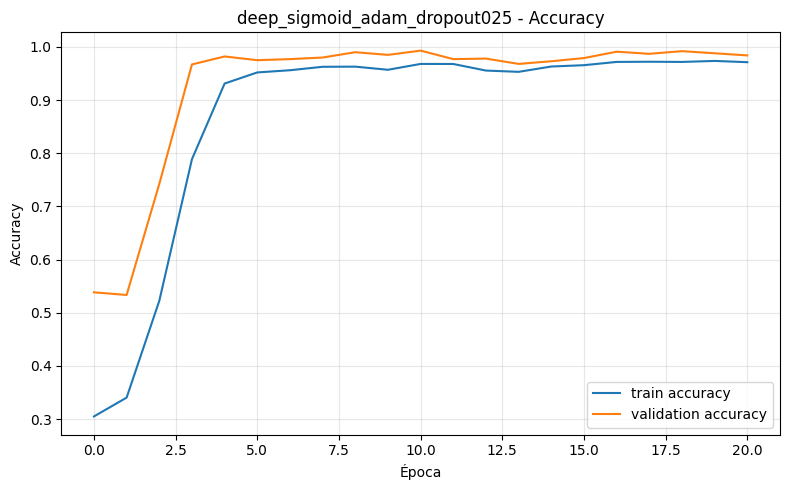

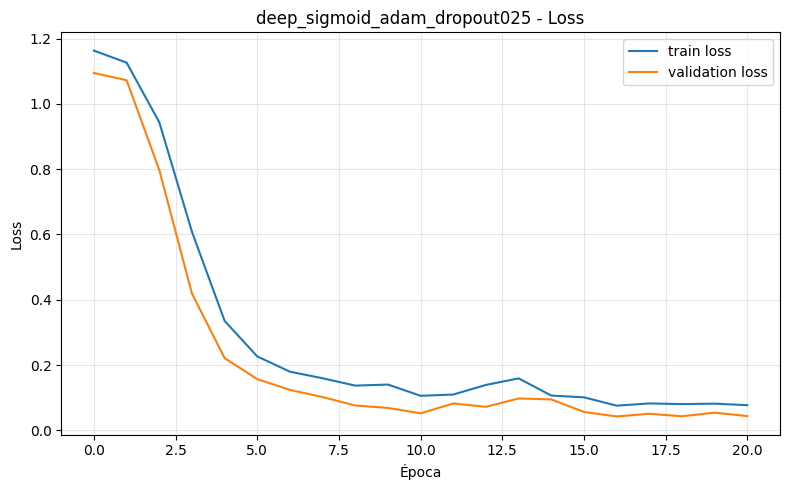

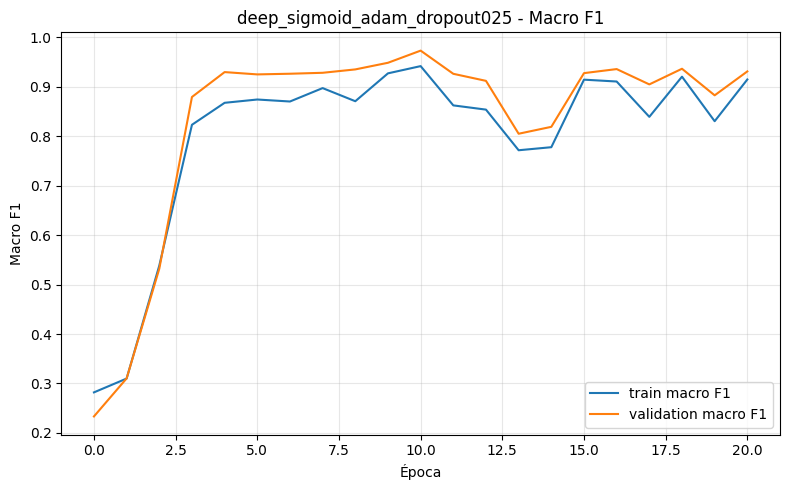

In [14]:
def plot_learning_curves(history, title="Curvas de aprendizaje"):
    hist = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="train accuracy")
    plt.plot(hist["val_accuracy"], label="validation accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="train loss")
    plt.plot(hist["val_loss"], label="validation loss")
    plt.title(title + " - Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if "train_macro_f1" in hist and "val_macro_f1" in hist:
        plt.figure(figsize=(8, 5))
        plt.plot(hist["train_macro_f1"], label="train macro F1")
        plt.plot(hist["val_macro_f1"], label="validation macro F1")
        plt.title(title + " - Macro F1")
        plt.xlabel("Época")
        plt.ylabel("Macro F1")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    elif "val_macro_f1" in hist:
        plt.figure(figsize=(8, 5))
        plt.plot(hist["val_macro_f1"], label="validation macro F1")
        plt.title(title + " - Macro F1")
        plt.xlabel("Época")
        plt.ylabel("Macro F1")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Este history no contiene Macro F1. Reentrena el modelo con el callback actualizado.")


plot_learning_curves(histories[best_model_name], title=best_model_name)


## 15. Matriz de confusión y reporte final del mejor modelo

              precision    recall  f1-score   support

         Low     1.0000    1.0000    1.0000         6
      Medium     0.9956    1.0000    0.9978       455
        High     1.0000    0.9963    0.9981       539

    accuracy                         0.9980      1000
   macro avg     0.9985    0.9988    0.9986      1000
weighted avg     0.9980    0.9980    0.9980      1000



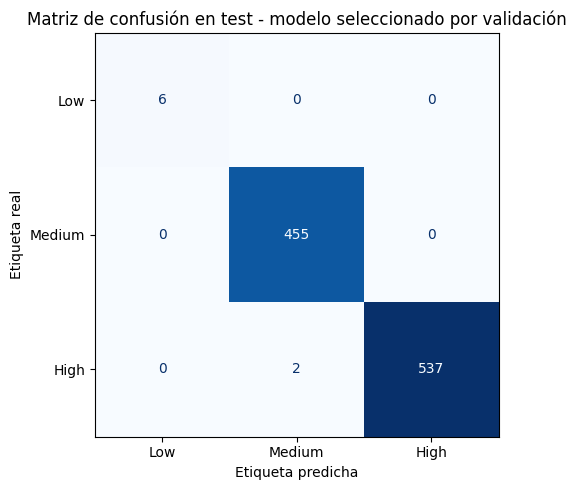

In [15]:
y_prob_best = best_model.predict(x_test, verbose=0)
y_pred_best = y_prob_best.argmax(axis=1)
y_true_test = np.asarray(y_test_int)

print(classification_report(
    y_true_test,
    y_pred_best,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_true_test, y_pred_best, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Matriz de confusión en test - modelo seleccionado por validación")
ax.set_xlabel("Etiqueta predicha")
ax.set_ylabel("Etiqueta real")
plt.tight_layout()
plt.show()


## 16. Exportar resultados para el informe

Esta celda guarda:

- tabla de resultados en CSV;
- tabla LaTeX para Overleaf;
- mejor modelo en formato `.keras`;
- matriz de confusión del mejor modelo;
- configuración usada en JSON.

In [16]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    results_df.to_csv(OUTPUT_DIR / "summary_results.csv", index=False)
    final_table.to_csv(OUTPUT_DIR / "final_table_report.csv", index=False)
    class_weight_table.to_csv(OUTPUT_DIR / "class_weights.csv", index=False)

    best_model.save(OUTPUT_DIR / "best_model.keras")

    # Guardar matriz de confusión
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title("Matriz de confusión en test - modelo seleccionado por validación")
    ax.set_xlabel("Etiqueta predicha")
    ax.set_ylabel("Etiqueta real")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "confusion_matrix_best_model.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Guardar curvas de Macro F1 del mejor modelo
    best_hist = histories[best_model_name].history

    if "train_macro_f1" in best_hist and "val_macro_f1" in best_hist:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(best_hist["train_macro_f1"], label="train macro F1")
        ax.plot(best_hist["val_macro_f1"], label="validation macro F1")
        ax.set_title("Modelo final - Macro F1")
        ax.set_xlabel("Época")
        ax.set_ylabel("Macro F1")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "curve_macro_f1_best_model.png", dpi=300, bbox_inches="tight")
        # Se guarda también con el nombre anterior para no romper referencias antiguas.
        plt.savefig(OUTPUT_DIR / "curve_val_macro_f1_best_model.png", dpi=300, bbox_inches="tight")
        plt.close(fig)
    elif "val_macro_f1" in best_hist:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(best_hist["val_macro_f1"], label="validation macro F1")
        ax.set_title("Modelo final - Macro F1 en validación")
        ax.set_xlabel("Época")
        ax.set_ylabel("Macro F1")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "curve_macro_f1_best_model.png", dpi=300, bbox_inches="tight")
        plt.savefig(OUTPUT_DIR / "curve_val_macro_f1_best_model.png", dpi=300, bbox_inches="tight")
        plt.close(fig)

    # Guardar curva de accuracy del mejor modelo
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(best_hist["accuracy"], label="train accuracy")
    ax.plot(best_hist["val_accuracy"], label="validation accuracy")
    ax.set_title("Modelo final - Accuracy")
    ax.set_xlabel("Época")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "curve_accuracy_best_model.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Guardar curva de loss del mejor modelo
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(best_hist["loss"], label="train loss")
    ax.plot(best_hist["val_loss"], label="validation loss")
    ax.set_title("Modelo final - Loss")
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "curve_loss_best_model.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Tabla en formato LaTeX para Overleaf
    latex_cols = [
        "model_name",
        "best_train_macro_f1",
        "best_val_macro_f1",
        "trainable_params",
        "test_accuracy",
        "macro_f1",
        "Low_f1",
        "epochs_trained",
    ]

    latex_table = results_df[latex_cols].copy()
    latex_str = latex_table.to_latex(index=False, float_format="%.4f")
    (OUTPUT_DIR / "table_results_overleaf.tex").write_text(
        latex_str,
        encoding="utf-8"
    )

    # Configuración del experimento
    experiment_config = {
        "DATA_PATH": str(DATA_PATH),
        "TARGET_COL": TARGET_COL,
        "CLASS_NAMES": CLASS_NAMES,
        "CLASS_TO_INT": CLASS_TO_INT,
        "RANDOM_STATE": RANDOM_STATE,
        "TEST_SIZE": TEST_SIZE,
        "VAL_SIZE_TOTAL": VAL_SIZE_TOTAL,
        "MAX_EPOCHS": MAX_EPOCHS,
        "BATCH_SIZE": BATCH_SIZE,
        "PATIENCE": PATIENCE,
        "LR_PATIENCE": LR_PATIENCE,
        "MIN_DELTA": MIN_DELTA,
        "best_model_name": best_model_name,
        "selection_metric_report": "best_val_macro_f1",
        "final_test_metric": "macro_f1_test",
        "monitor_metric_training": "val_macro_f1",
    }

    (OUTPUT_DIR / "experiment_config.json").write_text(
        json.dumps(experiment_config, indent=4, ensure_ascii=False),
        encoding="utf-8",
    )

    print(f"Resultados guardados en: {OUTPUT_DIR.resolve()}")
    print("Archivos generados:")

    for path in sorted(OUTPUT_DIR.iterdir()):
        print("-", path.name)

else:
    print("SAVE_OUTPUTS = False. No se guardan archivos.")


Resultados guardados en: C:\Users\USUARIO\OneDrive\Trabajo\outputs_burnout_unified
Archivos generados:
- best_model.keras
- class_distribution.png
- class_distribution_and_weights.png
- class_weights.csv
- class_weights.png
- confusion_matrix_best_model.png
- curve_accuracy_best_model.png
- curve_loss_best_model.png
- curve_macro_f1_best_model.png
- curve_val_macro_f1_best_model.png
- experiment_config.json
- final_table_report.csv
- keras_tuner_burnout_unified
- summary_results.csv
- table_results_overleaf.tex
